In [97]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames
using CSV

In [98]:
using Revise
using Newtrinos


In [99]:
# STANDARD MODEL

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);


[ Info: Loading Gerda data


In [100]:
par= Newtrinos.get_params(experiments)

(m₀ = 0.1, Δm²₂₁ = 7.53e-5, Δm²₃₁ = -0.0024, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [101]:
# NNATURALNESS

using Revise
using Newtrinos

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);

par= Newtrinos.get_params(experiments)

#matrix=Newtrinos.osc.get_matrices(osc_cfg.flavour)(par)

[ Info: Loading Gerda data


(N = 100.0, m₀ = 1.0e-6, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = -0.0024, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

Scans NN

In [113]:

all_priors = Newtrinos.get_priors(experiments)

m0=1e-2

par= merge(par, (m₀ =m0,))
  
vars_to_scan = (r=31, N=31)  

modified_priors = (
    N = all_priors.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    

likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)


Progress: 100%|█████████████████████████████████████████| Time: 0:00:09


NewtrinosResult((r = [0.0, 0.03333333333333333, 0.06666666666666667, 0.1, 0.13333333333333333, 0.16666666666666666, 0.2, 0.23333333333333334, 0.26666666666666666, 0.3  …  0.7, 0.7333333333333333, 0.7666666666666667, 0.8, 0.8333333333333334, 0.8666666666666667, 0.9, 0.9333333333333333, 0.9666666666666667, 1.0], N = [1.0, 7.633333333333333, 14.266666666666666, 20.900000000000002, 27.53333333333333, 34.166666666666664, 40.800000000000004, 47.43333333333334, 54.06666666666666, 60.699999999999996  …  140.29999999999998, 146.93333333333334, 153.56666666666666, 160.20000000000002, 166.83333333333334, 173.46666666666667, 180.1, 186.73333333333335, 193.36666666666667, 200.0]), (m₀ = [0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01; … ; 0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [-0.0024 -0.0024 … -0.0024 -0.0024; -0.0024 -0.0024 … -0.

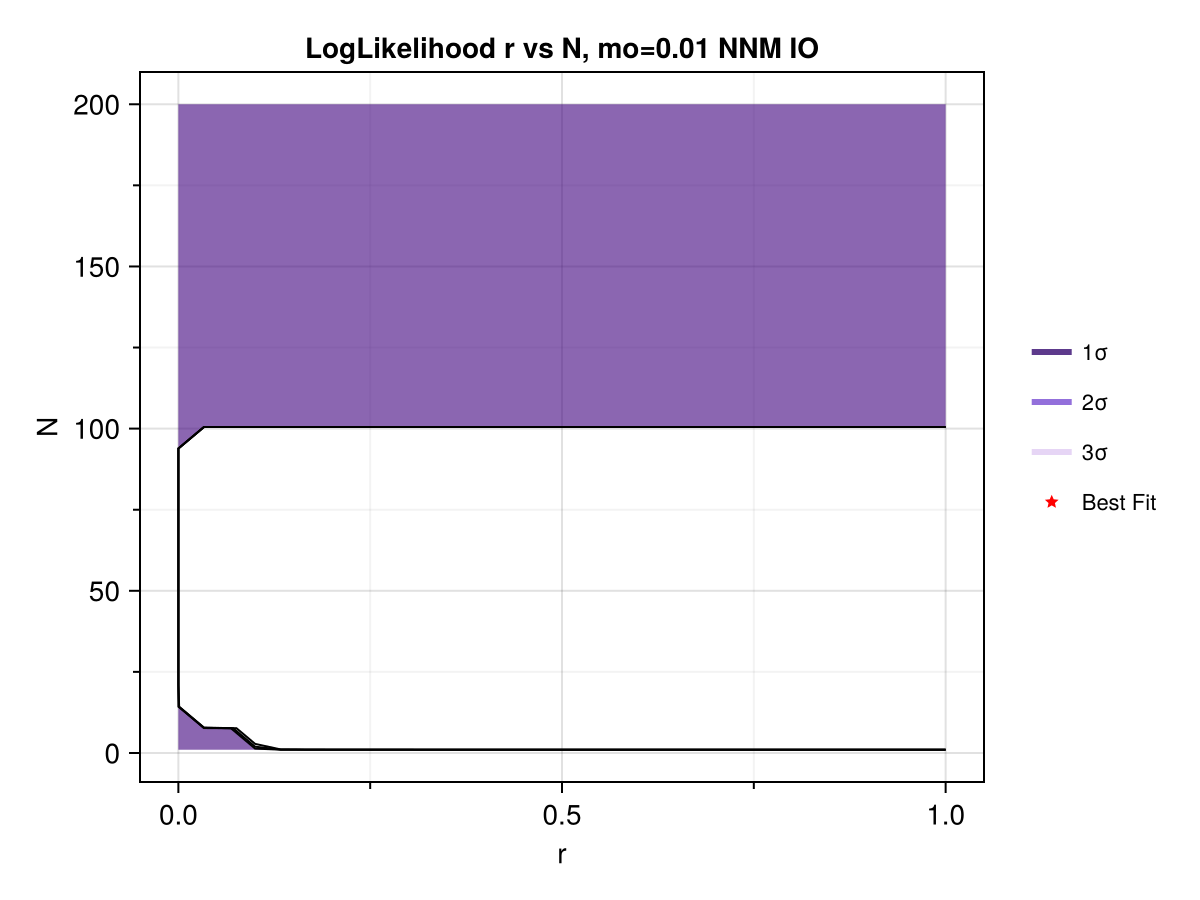

In [114]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="LogLikelihood r vs N, mo=$m0 NNM IO", log=0, mass=0)
display("image/png", img)
save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/gerda_rN_NNM_IO_m0=$m0.png", img)

In [109]:

all_priors = Newtrinos.get_priors(experiments)

r=1

par= merge(par, (r=r,))
  
vars_to_scan = ( m₀=31, N=31)  

modified_priors = (
    N = all_priors.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    

likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)


Progress: 100%|█████████████████████████████████████████| Time: 0:00:09


NewtrinosResult((m₀ = [1.0e-6, 0.0333343, 0.0666676, 0.1000009, 0.13333419999999999, 0.1666675, 0.2000008, 0.2333341, 0.26666739999999994, 0.30000069999999995  …  0.7000003, 0.7333335999999999, 0.7666669, 0.8000002, 0.8333335000000001, 0.8666668000000001, 0.9000001, 0.9333334, 0.9666667, 1.0], N = [1.0, 7.633333333333333, 14.266666666666666, 20.900000000000002, 27.53333333333333, 34.166666666666664, 40.800000000000004, 47.43333333333334, 54.06666666666666, 60.699999999999996  …  140.29999999999998, 146.93333333333334, 153.56666666666666, 160.20000000000002, 166.83333333333334, 173.46666666666667, 180.1, 186.73333333333335, 193.36666666666667, 200.0]), (r = [1 1 … 1 1; 1 1 … 1 1; … ; 1 1 … 1 1; 1 1 … 1 1], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [-0.0024 -0.0024 … -0.0024 -0.0024; -0.0024 -0.0024 … -0.0024 -0.0024; … ; -0.0024 -0.0024 … -0.0024 -0.0024; -0.0024 -0.00

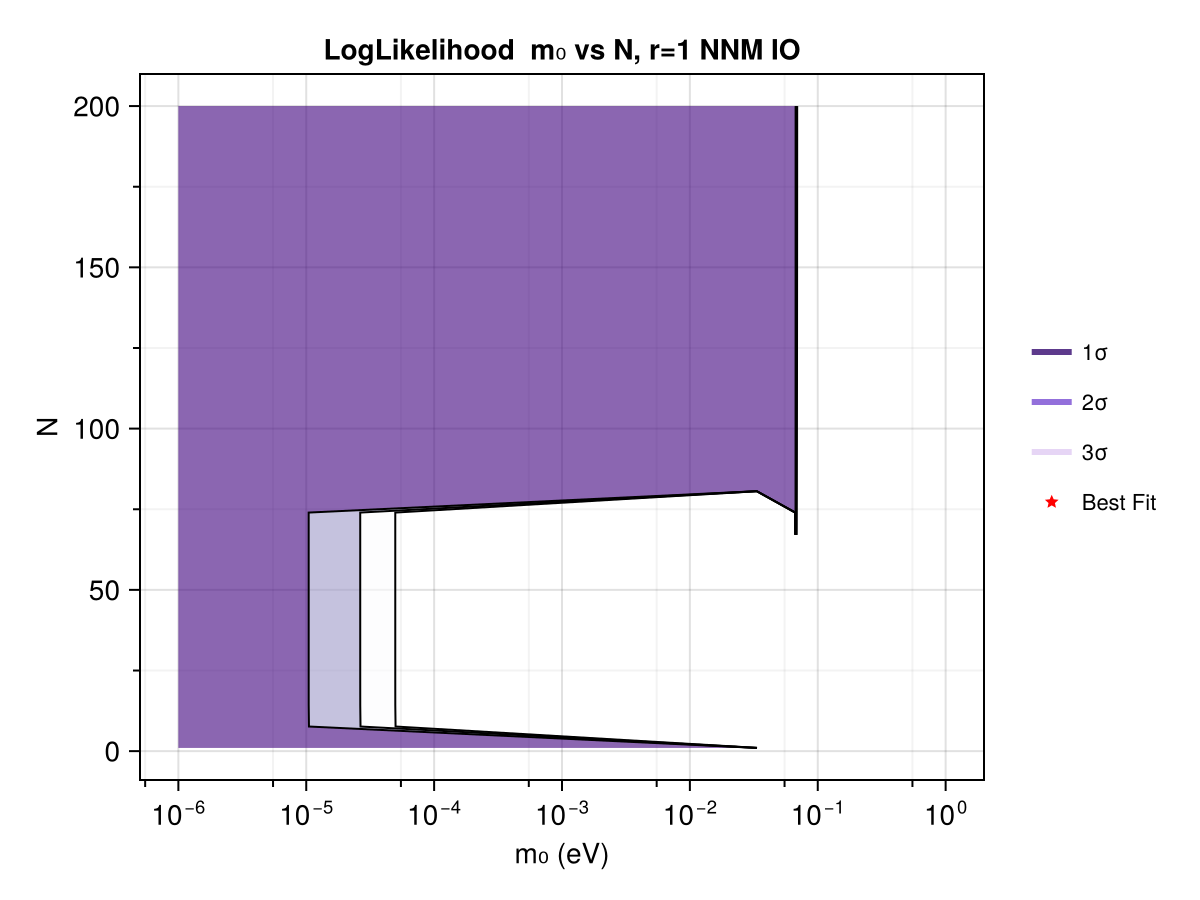

In [110]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="LogLikelihood  m₀ vs N, r=$r NNM IO", log=1, mass=1)
display("image/png", img)
save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/gerda_m₀N_NNM_IO_r=$r.png", img)

In [111]:

all_priors = Newtrinos.get_priors(experiments)

N=100

par= merge(par, (N=N,))
  
vars_to_scan = ( r=31, m₀ =31)  

modified_priors = (
    N = all_priors.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    

likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)


Progress: 100%|█████████████████████████████████████████| Time: 0:00:09


NewtrinosResult((r = [0.0, 0.03333333333333333, 0.06666666666666667, 0.1, 0.13333333333333333, 0.16666666666666666, 0.2, 0.23333333333333334, 0.26666666666666666, 0.3  …  0.7, 0.7333333333333333, 0.7666666666666667, 0.8, 0.8333333333333334, 0.8666666666666667, 0.9, 0.9333333333333333, 0.9666666666666667, 1.0], m₀ = [1.0e-6, 0.0333343, 0.0666676, 0.1000009, 0.13333419999999999, 0.1666675, 0.2000008, 0.2333341, 0.26666739999999994, 0.30000069999999995  …  0.7000003, 0.7333335999999999, 0.7666669, 0.8000002, 0.8333335000000001, 0.8666668000000001, 0.9000001, 0.9333334, 0.9666667, 1.0]), (N = [100 100 … 100 100; 100 100 … 100 100; … ; 100 100 … 100 100; 100 100 … 100 100], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [-0.0024 -0.0024 … -0.0024 -0.0024; -0.0024 -0.0024 … -0.0024 -0.0024; … ; -0.0024 -0.0024 … -0.0024 -0.0024; -0.0024 -0.0024 … -0.0024 -0.0024], δCP = [1.0 1.0

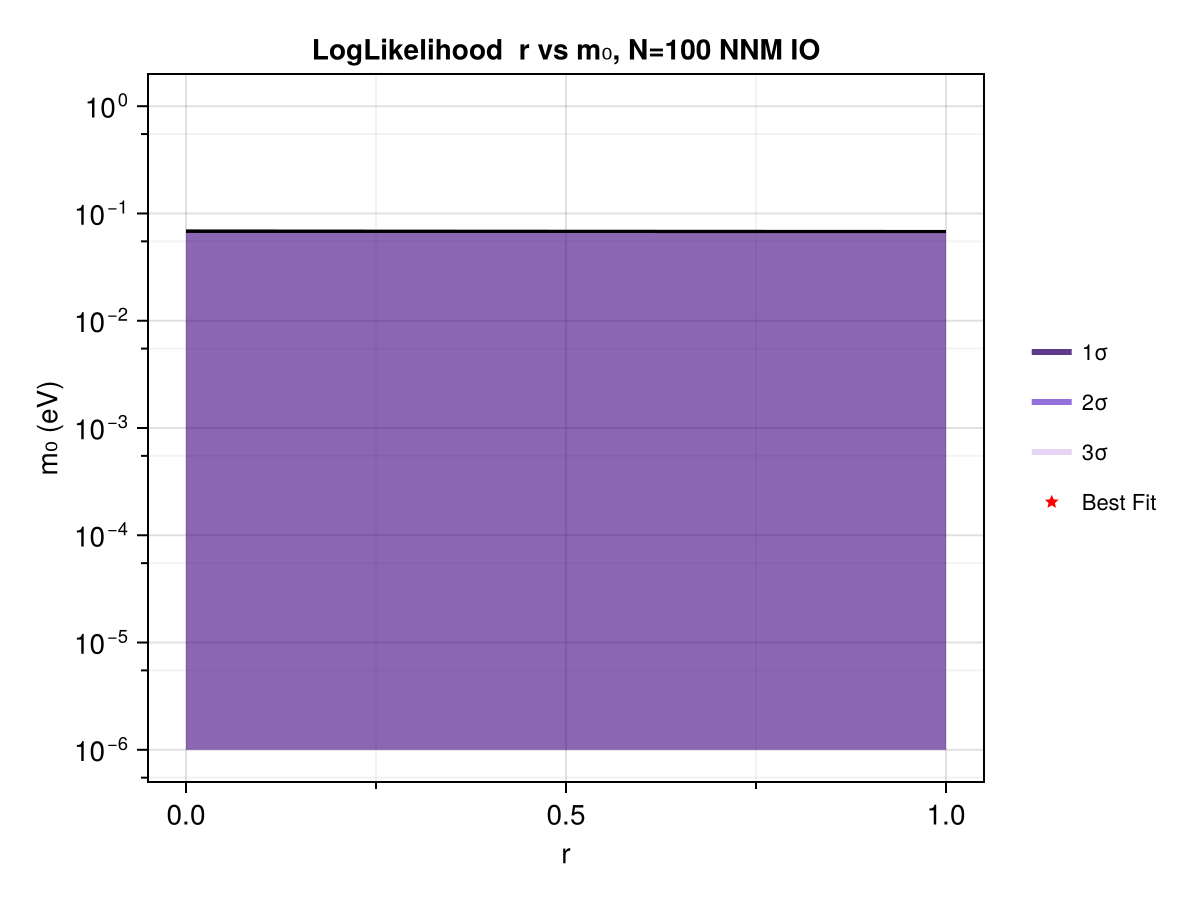

In [112]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="LogLikelihood  r vs m₀, N=$N NNM IO", log=2, mass=2)
display("image/png", img)
save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/gerda_rm₀_NNM_IO_N=$N.png", img)

Mixing angles

In [ ]:
par_p= merge(par, (m₀=0.1, r=1e-3, N=100))   

mass_e, mass_m, mass_t, angles_e, angles_m, angles_t = Newtrinos.gerda.mixing_angles( par_p, osc_cfg.flavour)

angles_e=angles_e[2:end-1]
angles_m=angles_m[2:end-1]
angles_t=angles_t[2:end-1]

mass_e=mass_e[2:end-1]
mass_m=mass_m[2:end-1]
mass_t=mass_t[2:end-1]


cont_e=mass_e.*(angles_e).^2
cont_m=mass_m.*(angles_m).^2
cont_t=mass_t.*(angles_t).^2






In [ ]:
using CairoMakie
# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  "i - number of sector",
    ylabel = "Matrix elements M_fi",
    title = "Matrix Elements - Gerda NNM IO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

i_range=1:length(angles_e)
# Plot the main curve
lines!(ax, i_range, abs.(angles_e),
    color = :green,
    linewidth = 2,
    label = "M_ei"
)

lines!(ax, i_range, abs.(angles_m),
    color = :blue,
    linewidth = 2,
    label = "M_mi"
)

lines!(ax, i_range, abs.(angles_t),
    color = :purple,
    linewidth = 2,
    label = "M_ti"
)
# Add legend
axislegend(ax, position = :rt)  # right bottom

#save("/home/sofialon/Newtrinos.jl/plot_final/gerda_checks/matrix_elements_N=100_m0=0.1_r=10^-3.png", fig)

display("image/png", fig)

In [ ]:

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  "i - number of sector",
    ylabel = "Contribution m_ei",
    title = "Contributions m_ei - Gerda NNM IO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

i_range=1:length(angles_e)
# Plot the main curve
lines!(ax, i_range, cont_e,
    color = :green,
    linewidth = 2,
    label = "m_ei"
)

lines!(ax, i_range, cont_m,
    color = :blue,
    linewidth = 2,
    label = "m_mi"
)

lines!(ax, i_range, cont_t,
    color = :purple,
    linewidth = 2,
    label = "m_ti"
)
# Add legend
axislegend(ax, position = :rt)  # right bottom

#save("/home/sofialon/Newtrinos.jl/plot_final/gerda_checks/m_contributions_N=100_m0=0.1_r=10^-3.png", fig)


display("image/png", fig)

Naive comparison 

In [ ]:
#predicted values comparison

using Revise
using Newtrinos


m0_range= LinRange(1e-7, 1e-2, 100)
r_range=LinRange(0, 1.0, 100)

predicted=[]

for m₀ in m0_range
    for r in r_range
        par_new = merge(par, (m₀=m₀, r=r, N=30))    
        pred, twosigma = Newtrinos.gerda.comparing_times(osc_cfg.flavour, experiments, par_new)
        push!(predicted, pred)
    end
end


In [ ]:
using CairoMakie

# plotting
observed_dist = Normal(experiments.gerda.assets.observed, 0.1*1e26)
observed_mean = mean(observed_dist)
observed_sigma = std(observed_dist)

# Get the actual lengths
n_r = length(r_range)
n_m0 = length(m0_range)

# Reshape predicted values into 2D array
predicted_2d = reshape(predicted, n_r, n_m0)

lower_bound = observed_mean - 2 * observed_sigma
upper_bound = observed_mean + 2 * observed_sigma
within_2sigma = (predicted_2d .>= lower_bound)

# Convert boolean matrix to numeric (1 for within, 0 for outside)
within_numeric = Float64.(within_2sigma)

# Create the plot with heatmap
fig = Figure(size=(1000, 800))
ax = Axis(fig[1, 1],
    ylabel="m₀",
    xlabel="r",
    title="Thalf Predictions - NNM NO, N=30",
    titlesize=24,
    xlabelsize=18,
    ylabelsize=18)

# Use heatmap with blue/green colormap
heatmap!(ax, r_range, m0_range, within_numeric,
    colormap=[:lightblue, :blue])

# Add legend box with text
text!(ax, 0.98, 0.98,
    text="Blue: Within 2σ",
    space=:relative, fontsize=14, align=(:right, :top),
    color=:black)

# Draw a box around the legend using lines
lines!(ax, [0.85, 0.99, 0.99, 0.85, 0.85], [0.90, 0.90, 0.99, 0.99, 0.90],
    space=:relative, color=:black, linewidth=2)

#save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/Thalf_NNM_NO_rm0_N=30.png", fig)
display(fig)

In [ ]:


N_range= LinRange(1, 50, 100)
r_range=LinRange(0, 1.0, 100)

predicted_N=[]

for N in N_range
    for r in r_range
        par_new = merge(par, (N=N, r=r, m₀=0.001))    
        pred, twosigma = Newtrinos.gerda.comparing_times(osc_cfg.flavour, experiments, par_new)
        push!(predicted_N, pred)
    end
end



In [ ]:
using CairoMakie

# Get the actual lengths
n_r = length(r_range)
n_N = length(N_range)



# Reshape predicted values into 2D array
predicted_2d = reshape(predicted_N, n_r, n_N)

lower_bound = observed_mean - 2 * observed_sigma
upper_bound = observed_mean + 2* observed_sigma

within_2sigma = (predicted_2d .>= lower_bound) #.& (predicted_2d .<= upper_bound)
# Convert boolean matrix to numeric (1 for within, 0 for outside)
within_numeric = Float64.(within_2sigma)

# Create the plot with heatmap
fig1 = Figure(size=(1000, 800))
ax1 = Axis(fig1[1, 1],
    ylabel="N", 
    xlabel="r",
    title="Thalf Predictions - NNM NO, m0=0.001",
    titlesize=24,
    xlabelsize=18,
    ylabelsize=18)

# Use heatmap with blue/green colormap
heatmap!(ax1, r_range, N_range, within_numeric,
    colormap=[:lightblue, :blue])

# Add legend box with text
text!(ax1, 0.98, 0.98, 
    text="Blue: Within 2σ",
    space=:relative, fontsize=14, align=(:right, :top),
    color=:black)

# Draw a box around the legend using lines
lines!(ax1, [0.85, 0.99, 0.99, 0.85, 0.85], [0.92, 0.92, 0.99, 0.99, 0.92],
    space=:relative, color=:black, linewidth=2)

#save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/Thalf_NNM_NO_rN_m0=0.001.png", fig1)
display(fig1)